In [40]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [41]:
x_train=np.array([1.0,2.0])
y_train=np.array([300.0,500.0])
print(f"x_train = {x_train}")
print(f"y_train = {y_train}")

x_train = [1. 2.]
y_train = [300. 500.]


In [42]:
print(f"x_train.shape:{x_train.shape}")
m=x_train.shape[0]
print(f"Number of training examples={m}")

x_train.shape:(2,)
Number of training examples=2


In [43]:
m=len(x_train)
print(f"Number of training examples={m}")

Number of training examples=2


In [44]:
for i in range(0,2):
    x_i=x_train[i]
    y_i=y_train[i]
    print(f"(x^({i}), y^({i})) = ({x_i}, {y_i})")

(x^(0), y^(0)) = (1.0, 300.0)
(x^(1), y^(1)) = (2.0, 500.0)


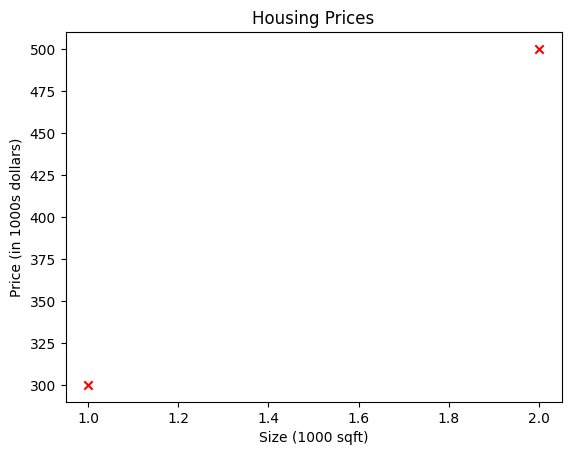

In [45]:
plt.scatter(x_train,y_train,marker='x',c='r')
plt.title("Housing Prices")
plt.ylabel("Price (in 1000s dollars)")
plt.xlabel("Size (1000 sqft)")
plt.show()

In [46]:
w=200
b=100
print(f"w: {w}")
print(f"b: {b}")

w: 200
b: 100


In [47]:
def compute_model_output(x,w,b):
    m=x.shape[0]
    f_wb=np.zeros(m)
    for i in range (m):
        f_wb[i]=w*x[i]+b
    return f_wb

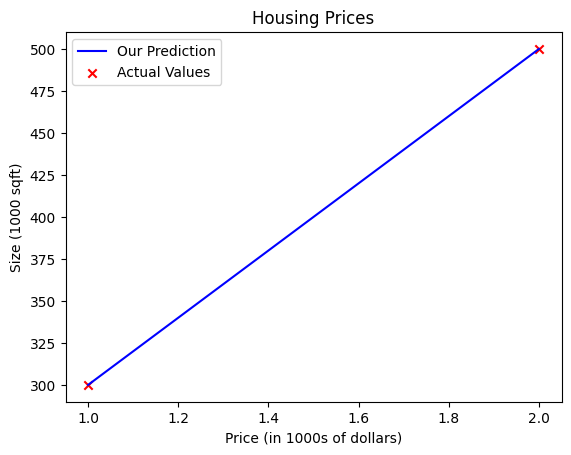

In [48]:
tmp_f_wb=compute_model_output(x_train,w,b)
plt.plot(x_train,tmp_f_wb,c='b',label='Our Prediction')
plt.scatter(x_train,y_train,marker='x',c='r',label='Actual Values')
plt.title("Housing Prices")
plt.xlabel("Price (in 1000s of dollars)")
plt.ylabel("Size (1000 sqft)")
plt.legend()
plt.show()

In [49]:
x_i=1.2
cost_1200sqft=w*x_i+b
print(f"${cost_1200sqft:.0f} thousand dollars")

$340 thousand dollars


In [50]:
def compute_cost(x,y,w,b):
    m=x.shape[0]
    cost=0
    for i in range(m):
        f_wb=w*x[i]+b
        cost+=(f_wb-y[i])**2
    total_cost=1/(2*m)*cost
    return total_cost

In [51]:
def compute_gradient(x,y,w,b):
    m=x.shape[0]
    dj_dw=0
    dj_db=0
    for i in range(m):
        f_wb=w*x[i]+b
        dj_dw+=(f_wb-y[i])*x[i]
        dj_db+=(f_wb-y[i])
    dj_dw/=m
    dj_db/=m
    return dj_dw,dj_db

In [52]:
def gradient_descent(x,y,w_in,b_in,alpha,num_iters,cost_function,gradient_function):
    w=w_in
    b=b_in
    for i in range(num_iters):
        dj_dw,dj_db=gradient_function(x,y,w,b)
        w=w-alpha*dj_dw
        b=b-alpha*dj_db
        if i%math.ceil(num_iters/10)==0:
            print(cost_function(x,y,w,b))
    return w,b

In [53]:
w_init=0
b_init=0
iterations=10000
tmp_alpha=1.0e-2
w_final,b_final=gradient_descent(x_train,y_train,w_init,b_init,tmp_alpha,iterations,compute_cost,compute_gradient)
print(f"w_final:{w_final:8.4f} b_final:{b_final:8.4f}")

79274.8125
3.4125109319154174
0.7928950684538176
0.1842287401041018
0.04280544807338754
0.0099458226969803
0.0023109065217603642
0.0005369378798549629
0.00012475722583692557
2.8987273914308145e-05
w_final:199.9929 b_final:100.0116


In [54]:
x_i=1.2
cost_1200sqft=w_final*x_i+b_final
print(f"Model prediction for 12000 sqft:{cost_1200sqft:0.1f}")

Model prediction for 12000 sqft:340.0
